# RNN

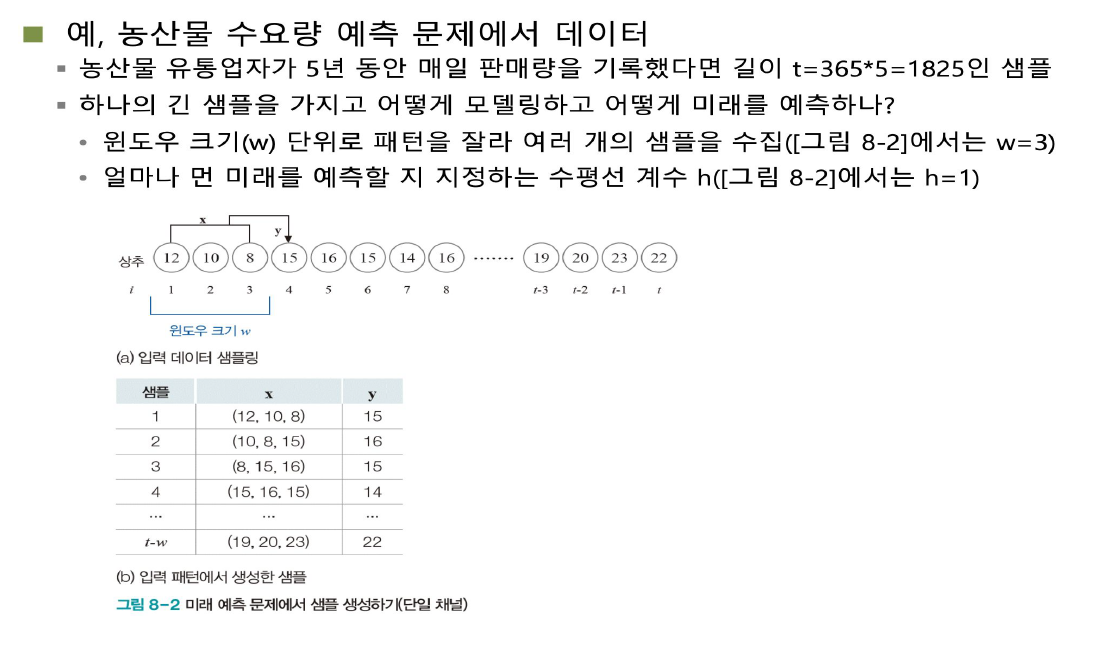

In [1]:
import numpy as np

In [2]:
# 시계열 (슬라이드에 있던 값)
series = np.array([12, 10, 8, 15, 16, 15, 14, 16, 19, 20, 23, 22])

# 2. 원도우와 수평선 계수를 이용해 x,y 샘플 만들기
def make_dataset(series, window_size=3, horizon=1):
    X = []  # 입력 패턴들 (x)
    y = []  # 타깃값들   (y)

    # i에서 시작해 window_size개를 x, 그 뒤 horizon번째 값을 y로 사용
    for i in range(len(series) - window_size - horizon + 1):
        x_i = series[i : i + window_size]                 # 예: [12, 10, 8]
        y_i = series[i + window_size + horizon - 1]       # 예: 15
        X.append(x_i)
        y.append(y_i)

    return np.array(X), np.array(y)

X, y = make_dataset(series, window_size=3, horizon=1)

for i in range(9):
    print(f"데이터 {i+1}번째 샘플")
    print("X :", X[i])
    print("y :", y[i])
    print("======="*10)

데이터 1번째 샘플
X : [12 10  8]
y : 15
데이터 2번째 샘플
X : [10  8 15]
y : 16
데이터 3번째 샘플
X : [ 8 15 16]
y : 15
데이터 4번째 샘플
X : [15 16 15]
y : 14
데이터 5번째 샘플
X : [16 15 14]
y : 16
데이터 6번째 샘플
X : [15 14 16]
y : 19
데이터 7번째 샘플
X : [14 16 19]
y : 20
데이터 8번째 샘플
X : [16 19 20]
y : 23
데이터 9번째 샘플
X : [19 20 23]
y : 22


In [3]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [4]:
# 케라스의 imdb에서 자료를 받아옴
# imdb: 영화리뷰 데이터셋
from tensorflow.keras.datasets import imdb

# 단어 500개만 끌어와서 쓰겠다
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
train_input.shape, test_input.shape

((25000,), (25000,))

In [6]:
train_target.shape, test_target.shape

((25000,), (25000,))

In [7]:
len(train_input[0])

218

In [8]:
len(train_input[1])

189

In [9]:
train_input[1][:10]

[1, 194, 2, 194, 2, 78, 228, 5, 6, 2]

In [10]:
train_target[:10]
# 1은 긍정, 0은 부정의 리뷰

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0])

In [11]:
print(train_input[0])
# 1은 문장의 시작을 알림
# 2는 어휘사전에 없는 단어를 사용함을 알려줌
# 0은 길이를 맞추는 패딩

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [12]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [13]:
len(train_input[0])

259

In [14]:
len(train_input[1])

520

In [15]:
train_input.shape, train_target.shape, val_input.shape, val_target.shape

((20000,), (20000,), (5000,), (5000,))

In [16]:
lengths = np.array([len(x) for x in train_input])

In [17]:
np.mean(lengths), np.median(lengths)

(np.float64(239.00925), np.float64(178.0))

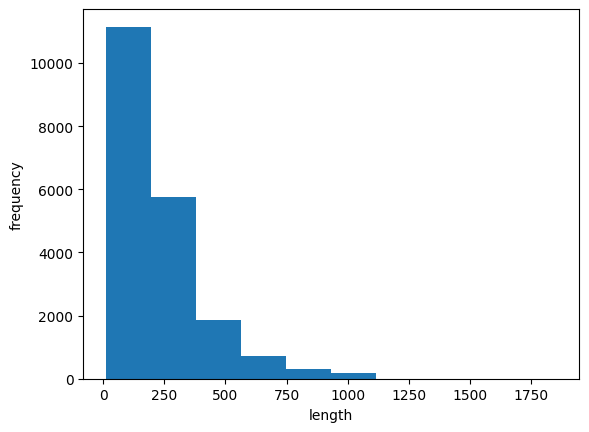

In [18]:
import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
train_seq = pad_sequences(train_input, maxlen=100)

In [21]:
train_seq.shape

(20000, 100)

In [22]:
train_seq[0]

array([ 10,   4,  20,   9,   2, 364, 352,   5,  45,   6,   2,   2,  33,
       269,   8,   2, 142,   2,   5,   2,  17,  73,  17, 204,   5,   2,
        19,  55,   2,   2,  92,  66, 104,  14,  20,  93,  76,   2, 151,
        33,   4,  58,  12, 188,   2, 151,  12, 215,  69, 224, 142,  73,
       237,   6,   2,   7,   2,   2, 188,   2, 103,  14,  31,  10,  10,
       451,   7,   2,   5,   2,  80,  91,   2,  30,   2,  34,  14,  20,
       151,  50,  26, 131,  49,   2,  84,  46,  50,  37,  80,  79,   6,
         2,  46,   7,  14,  20,  10,  10, 470, 158], dtype=int32)

In [23]:
train_input[0][-10:]

[6, 2, 46, 7, 14, 20, 10, 10, 470, 158]

In [24]:
train_seq[5]

array([  0,   0,   0,   0,   1,   2, 195,  19,  49,   2,   2, 190,   4,
         2, 352,   2, 183,  10,  10,  13,  82,  79,   4,   2,  36,  71,
       269,   8,   2,  25,  19,  49,   7,   4,   2,   2,   2,   2,   2,
        10,  10,  48,  25,  40,   2,  11,   2,   2,  40,   2,   2,   5,
         4,   2,   2,  95,  14, 238,  56, 129,   2,  10,  10,  21,   2,
        94, 364, 352,   2,   2,  11, 190,  24, 484,   2,   7,  94, 205,
       405,  10,  10,  87,   2,  34,  49,   2,   7,   2,   2,   2,   2,
         2, 290,   2,  46,  48,  64,  18,   4,   2], dtype=int32)

In [25]:
val_seq = pad_sequences(val_input, maxlen=100)

In [26]:
from tensorflow import keras

model = keras.Sequential()

model.add(keras.layers.SimpleRNN(8, input_shape=(100,500)))
model.add(keras.layers.Dense(1, activation='sigmoid'))

c:\Users\USER\miniconda3\envs\sesac\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
train_seq[0]

array([ 10,   4,  20,   9,   2, 364, 352,   5,  45,   6,   2,   2,  33,
       269,   8,   2, 142,   2,   5,   2,  17,  73,  17, 204,   5,   2,
        19,  55,   2,   2,  92,  66, 104,  14,  20,  93,  76,   2, 151,
        33,   4,  58,  12, 188,   2, 151,  12, 215,  69, 224, 142,  73,
       237,   6,   2,   7,   2,   2, 188,   2, 103,  14,  31,  10,  10,
       451,   7,   2,   5,   2,  80,  91,   2,  30,   2,  34,  14,  20,
       151,  50,  26, 131,  49,   2,  84,  46,  50,  37,  80,  79,   6,
         2,  46,   7,  14,  20,  10,  10, 470, 158], dtype=int32)

In [29]:
train_oh = keras.utils.to_categorical(train_seq)

In [30]:
train_oh.shape

(20000, 100, 500)

In [31]:
val_oh = keras.utils.to_categorical(val_seq)

In [33]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(
    optimizer=rmsprop,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_simple_rnn_model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    train_oh, train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_oh, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4969 - loss: 0.7024 - val_accuracy: 0.5002 - val_loss: 0.7008
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5082 - loss: 0.6971 - val_accuracy: 0.5012 - val_loss: 0.6976
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5200 - loss: 0.6937 - val_accuracy: 0.5068 - val_loss: 0.6950
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5296 - loss: 0.6909 - val_accuracy: 0.5158 - val_loss: 0.6929
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5404 - loss: 0.6885 - val_accuracy: 0.5278 - val_loss: 0.6910
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5513 - loss: 0.6863 - val_accuracy: 0.5400 - val_loss: 0.6895
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5614 - loss: 0.6842 - val_accuracy: 0.5408 - val_loss: 0.6881
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5690 - loss: 0.6821 - val_

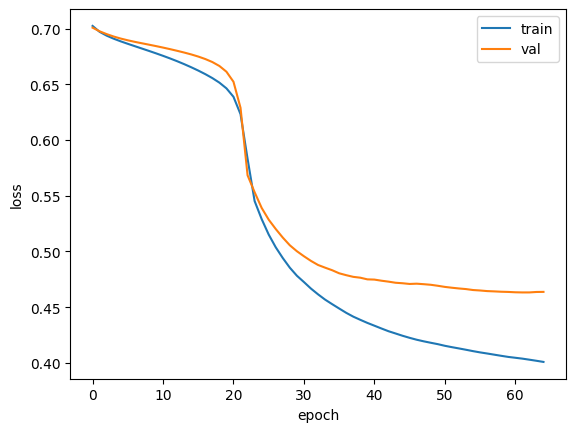

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 임베딩

이전 계산에서,
(20000, 100, 200) 은

    리뷰 = 2만개 = 샘플 수
    1리뷰의 총 단어수 = 100개
    1단어가 원-핫 인코딩 된 전체 리스트 길이 = 200

이었다. 그래서 (100,) 였던 샘플 하나가 (100,500) 으로 차원이 늘어 났었다.

그런데 이번에는 차원을

(100,16)으로 줄이면서도 단어간의 문맥이 반영되도록 변환해보자

이 변환을 임베딩이라 한다.

In [1]:
from tensorflow.keras.datasets import imdb

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

In [2]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [3]:
train_input.shape, train_target.shape, val_input.shape, val_target.shape

((20000,), (20000,), (5000,), (5000,))

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [5]:
train_seq.shape, val_seq.shape

((20000, 100), (5000, 100))

In [6]:
from tensorflow import keras
# from tensorflow.keras.layers import  Input

model2 = keras.Sequential()
# 원소 하나짜리 튜플
model2.add(keras.layers.Input(shape=(100,)))
model2.add(keras.layers.Embedding(200, 16))
model2.add(keras.layers.SimpleRNN(8))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,409 (13.32 KB)

 Trainable params: 3,409 (13.32 KB)

 Non-trainable params: 0 (0.00 B)

- 3200 = 200x16
- 200 = 16x8 + 8x8 + 8

In [7]:
from tensorflow import keras

rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(
    optimizer=rmsprop,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('best_simple_rnn_model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model2.fit(
    train_seq, train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_seq, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5617 - loss: 0.6848 - val_accuracy: 0.6094 - val_loss: 0.6717
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6222 - loss: 0.6651 - val_accuracy: 0.6498 - val_loss: 0.6543
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6560 - loss: 0.6464 - val_accuracy: 0.6606 - val_loss: 0.6430
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6797 - loss: 0.6286 - val_accuracy: 0.6714 - val_loss: 0.6247
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6904 - loss: 0.6133 - val_accuracy: 0.6630 - val_loss: 0.6235
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7010 - loss: 0.6008 - val_accuracy: 0.6924 - val_loss: 0.6021
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7113 - loss: 0.5883 - val_accuracy: 0.6854 - val_loss: 0.5989
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7184 - loss: 0.5778 - val_accu

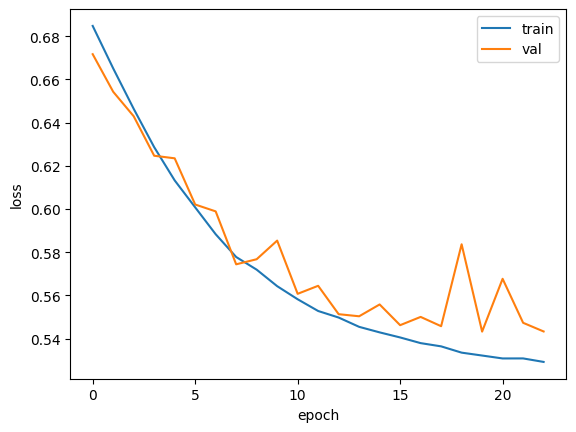

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# LSTM

## 아다마르곱
- 행렬의 같은 위치에 있는 원소끼리만 곱하는 연산

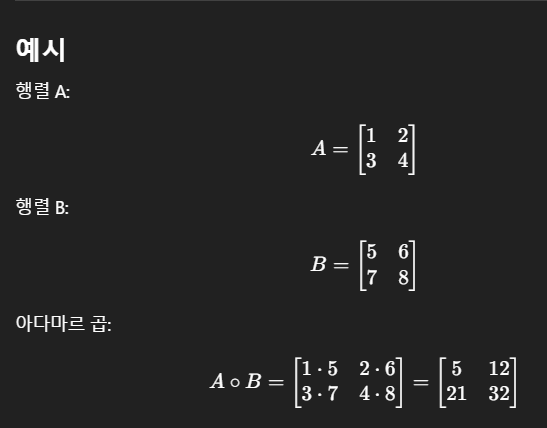

## gensimm 사용해보기
- 한글전용 Word2Vec

## 아이템 기반 인접 이웃 협업 필터링으로 개인화된 영화 추천

1. 사용자가 본 영화의 평점이 있다. (평점을 작성하지 않은 영화는 NaN이어서 0으로 처리)
2. 영화들의 코사인 유사도가 있다.
3. 사용자의 모든 영화평점을 유사도 기반으로 예측한다.
    - 사용자별로 모든 영화를 예측할 것이다.
4. 사용자별 영화별 예측평점이 높은 순으로 정렬한 후에 사용자가 보지 않은 영화를 추천한다.


**Weighted Rating Sum**

사용자 $ u $의 아이템 $ i $에 대한 평점 예측은 사용자 $ u $가 아이템 $ i $와 유사한 다른 아이템들($ N $개의 다른 아이템)의 합으로 계산하며, 아이템들 간의 유사도를 반영한 합으로 계산.

$
\hat{R}_{u,i} = \frac{\sum_{N} (S_{i,N} \times R_{u,N})}{\sum_{N} (|S_{i,N}|)}
$


- $\hat{R}_{u,i}$: 사용자 $ u $가 아이템 $ i $에 대해 가질 것으로 예측되는 평점
- $S_{i,N}$: 아이템 $ i $와 유사한 다른 아이템들의 유사도
- $R_{u,N}$: 사용자 $u$가 작성한 아이템 $ i $와 유사 아이템들의 평점

**사용자 $ u $의 아이템 들의 평점**

| Item | a | b | **c** | d | e |
|------|---|---|---|---|---|
| Rating | 5 | 4 | **1** | 3 | 2 |

**아이템 i와 사용자가 본 아이템간의 유사도**

|   | (i,a) | (i,b) | (i,c) | (i,d) | (i,e) |
|---|-------|-------|-------|-------|-------|
| **R_{u,i}** | 0.2 | 0.1 | **0.4** | 0.1 | 0.2 |

**계산:** 위 두개의 행렬에 대한 내적을 구한다.

$
5 \times 0.2 + 4 \times 0.1 + 1 \times 0.4 + 3 \times 0.1 + 2 \times 0.2 = 2.5
$
<br>
<br>
$
\hat{R}_{u,i} = \frac{(5 \times 0.2) + (4 \times 0.1) + (1 \times 0.4) + (3 \times 0.1) + (2 \times 0.2)}{0.2 + 0.1 + 0.4 + 0.1 + 0.2}
= \frac{1 + 0.4 + 0.4 + 0.3 + 0.4}{1} = \frac{2.5}{1} = 2.5
$

결과적으로, 사용자 $ u $가 아이템 $ i $에 대해 가질 것으로 예측되는 평점은 **2.5**이다.
